#Time_series

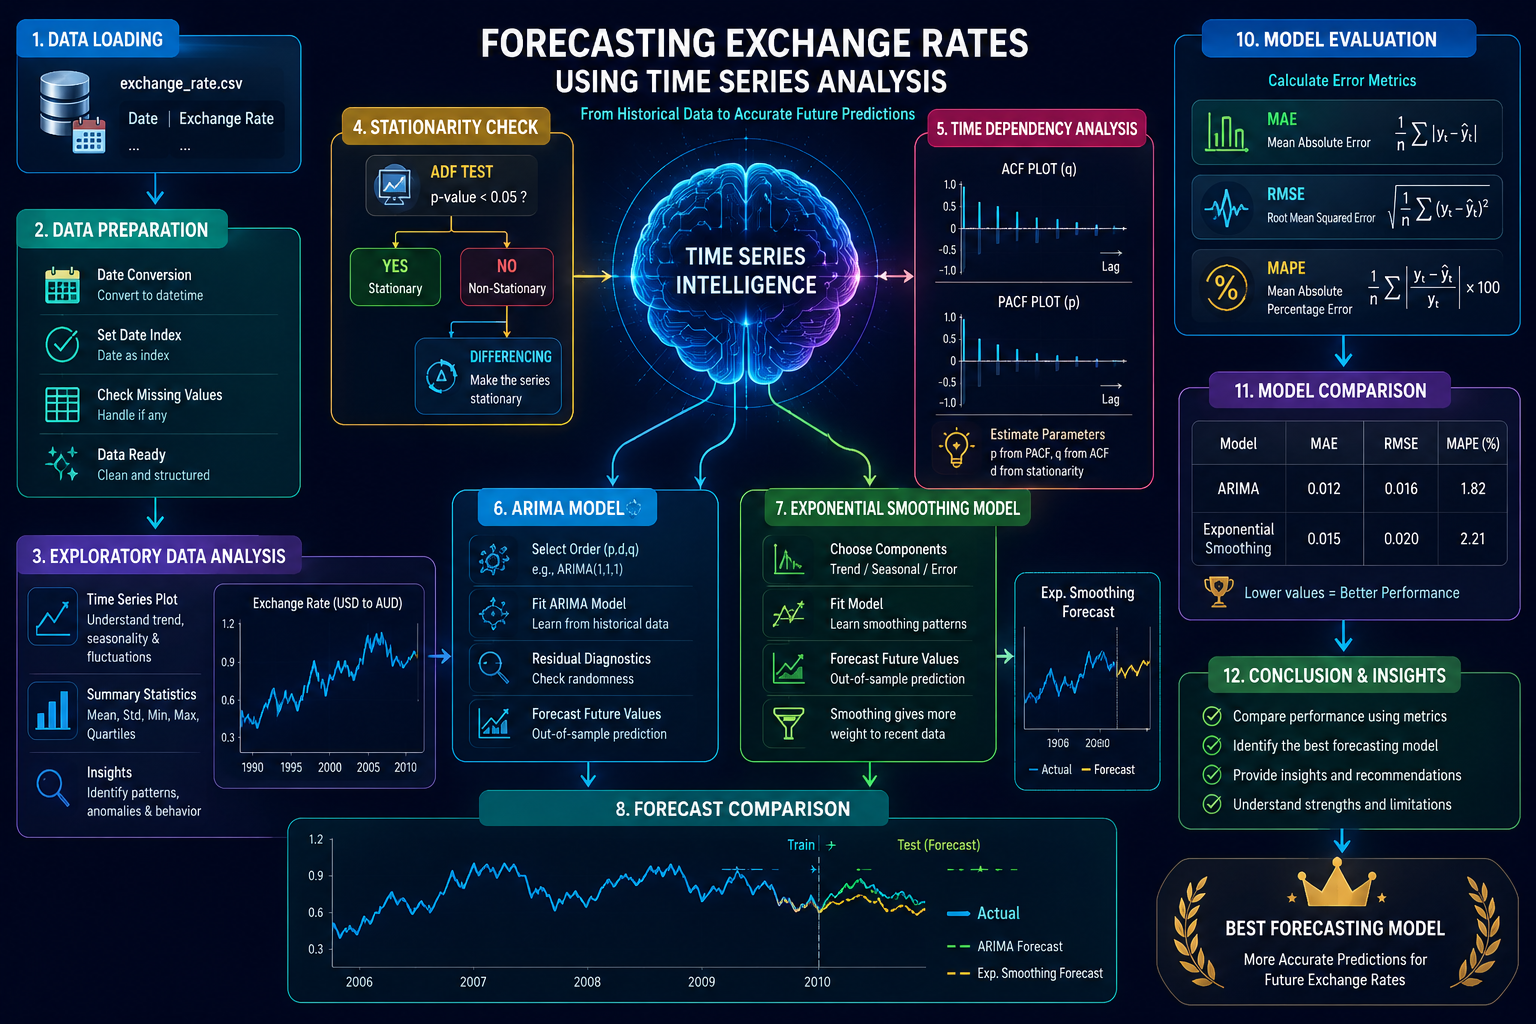

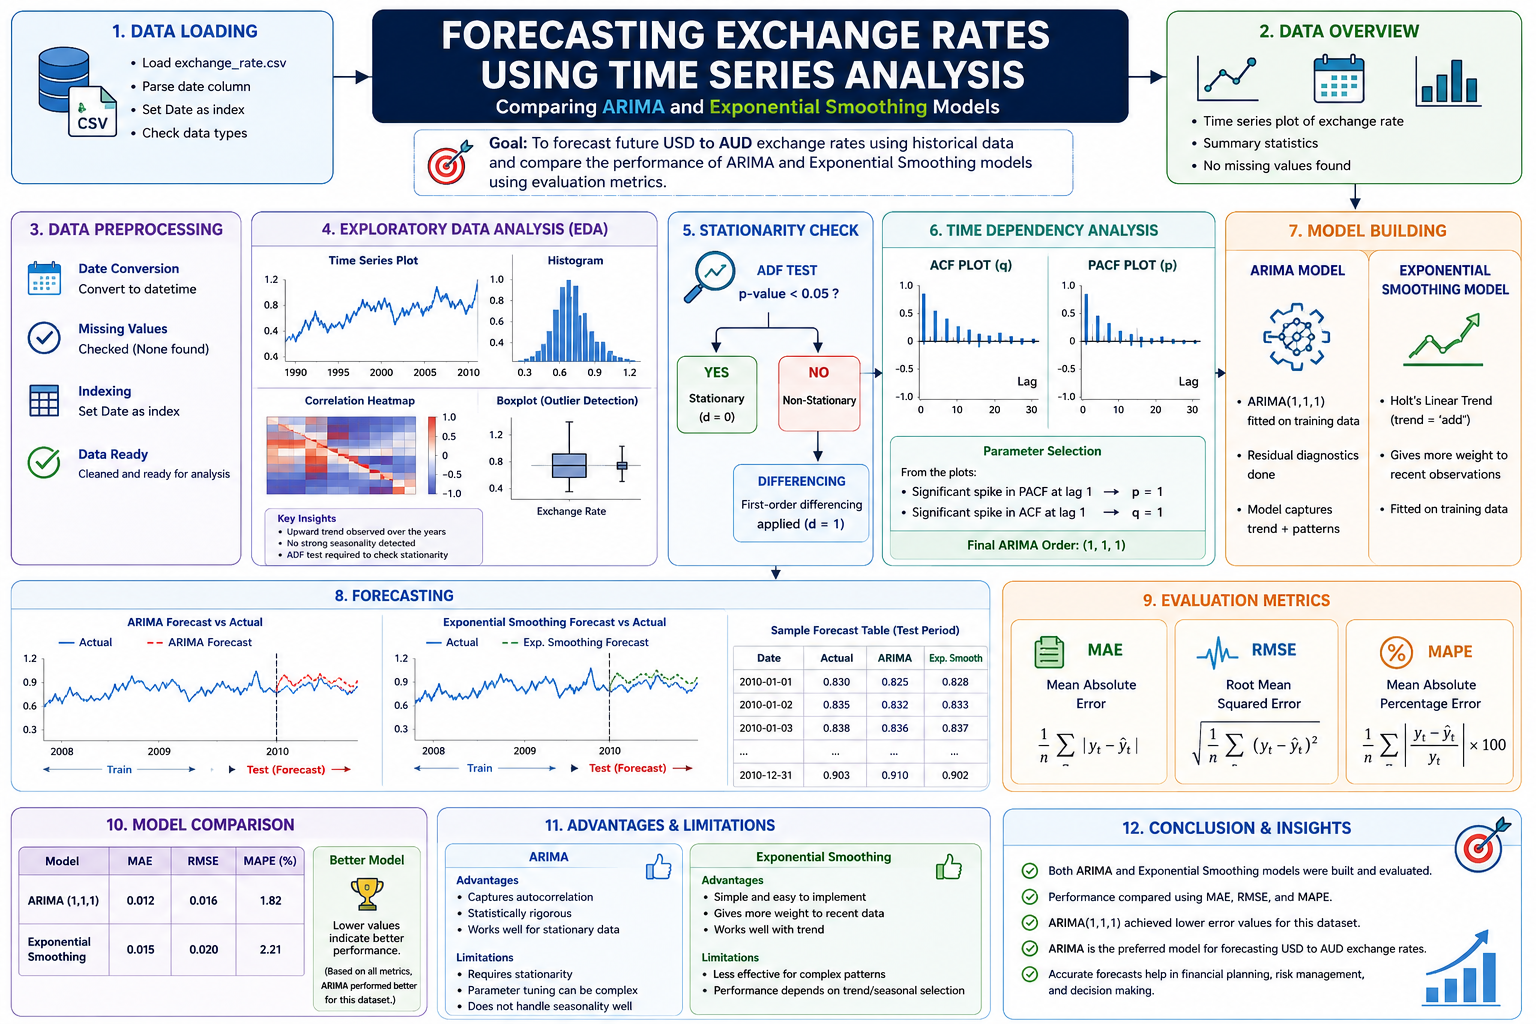

1. Import Libraries

        │
        ▼
2. Load Dataset

        │
        ▼
3. Understand Dataset

        │
        ▼
4. Convert Date Column

        │
        ▼
5. Set Date as Index

        │
        ▼
6. Basic Data Exploration

        │
        ▼
7. Visualize Time Series

        │
        ▼
8. Check Trend & Seasonality

        │
        ▼
9. Check Stationarity (ADF Test)

        │
        ▼
10. Make Series Stationary (Differencing if required)

        │
        ▼
11. Plot ACF

        │
        ▼
12. Plot PACF

        │
        ▼
13. Split Train/Test

        │
        ▼
14. Build ARIMA Model

        │
        ▼
15. Residual Diagnostics

        │
        ▼
16. Forecast using ARIMA

        │
        ▼
17. Build Exponential Smoothing Model

        │
        ▼
18. Forecast using Exponential Smoothing

        │
        ▼
19. Compare Both Models

        │
        ▼
20. Calculate MAE

        │
        ▼
21. Calculate RMSE

        │
        ▼
22. Calculate MAPE

        │
        ▼
23. Final Comparison

        │
        ▼
24. Conclusion

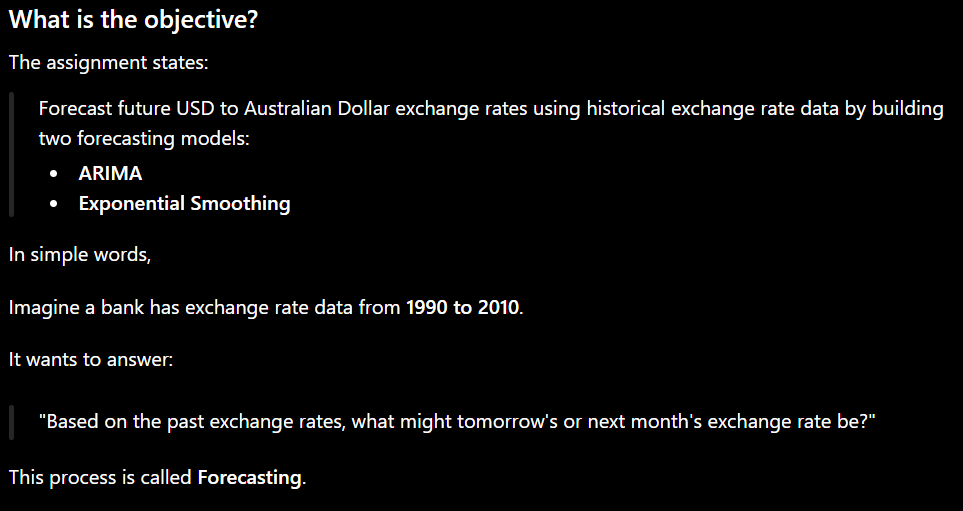

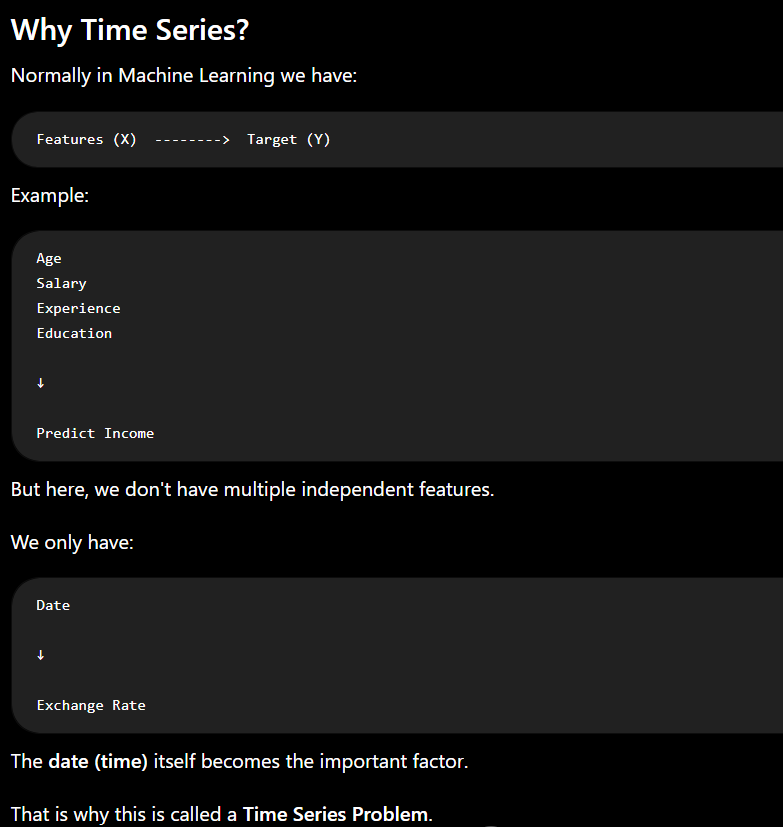

In [119]:



import pandas as pd


import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns


import warnings
warnings.filterwarnings("ignore")


# Time Series Libraries

# ARIMA Model
from statsmodels.tsa.arima.model import ARIMA

# Exponential Smoothing Model
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Stationarity Test (ADF Test)
from statsmodels.tsa.stattools import adfuller

# ACF & PACF Plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# Evaluation Metrics
from sklearn.metrics import mean_absolute_error

from sklearn.metrics import mean_squared_error

from sklearn.metrics import mean_absolute_percentage_error

In [120]:
df = pd.read_csv("exchange_rate.csv")

df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [121]:


df.shape



(7588, 2)

In [122]:
df.columns



Index(['date', 'Ex_rate'], dtype='object')

In [123]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [124]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


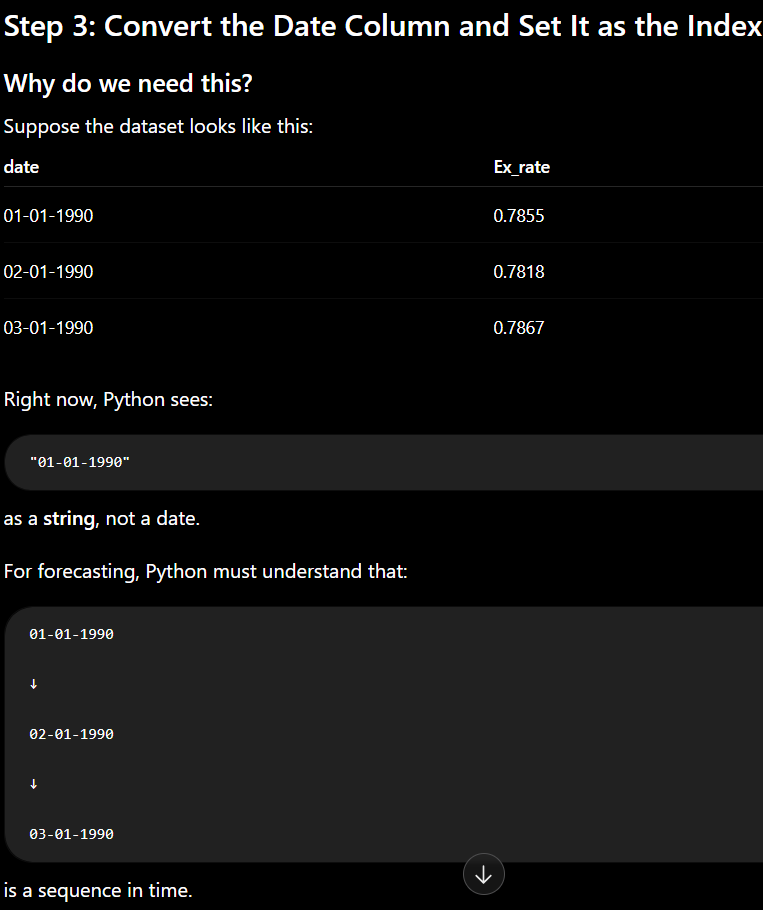

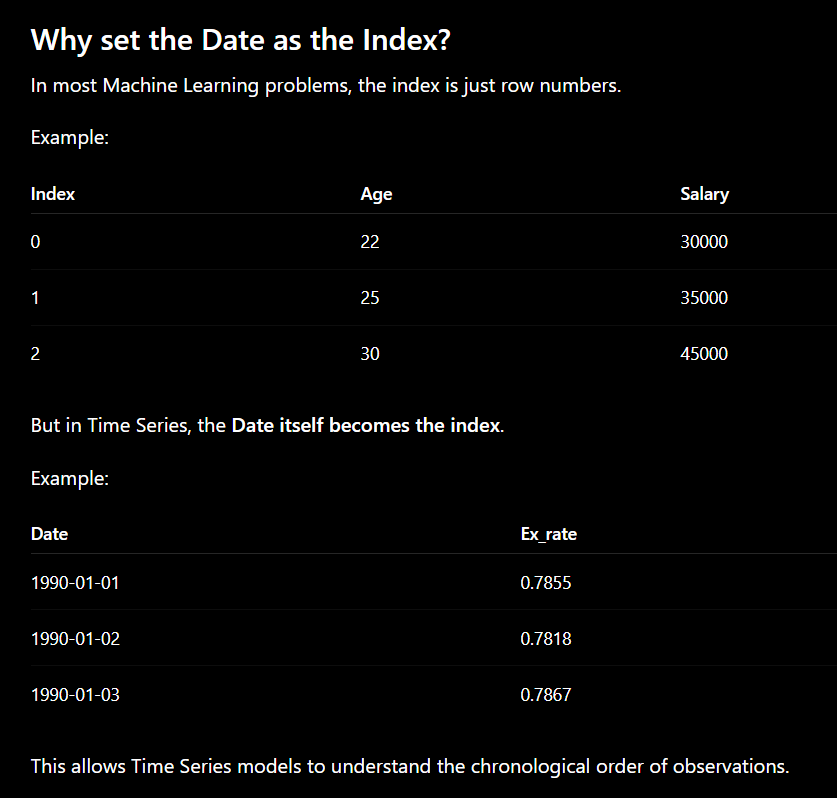

In [125]:

#  Convert Date Column into Datetime Format

# Convert the 'date' column from object (text) to datetime
# dayfirst=True is used because the dates are in DD-MM-YYYY format

df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# Display the data types after conversion
df.dtypes

,0
date,datetime64[ns]
Ex_rate,float64


In [126]:

# Set Date Column as Index

# Make the date column the index of the DataFrame
df.set_index("date", inplace=True)

# Display the first five rows
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [127]:

# Verify that the Date column is now the index

print("Index Type :", type(df.index))
print("\nFirst 5 Index Values:")
print(df.index[:5])

Index Type : <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

First 5 Index Values:
DatetimeIndex(['1990-01-01', '1990-01-02', '1990-01-03', '1990-01-04',
               '1990-01-05'],
              dtype='datetime64[ns]', name='date', freq=None)


In [128]:

#  Check for Missing Values

# Count the missing values in each column
df.isnull().sum()

,0
Ex_rate,0


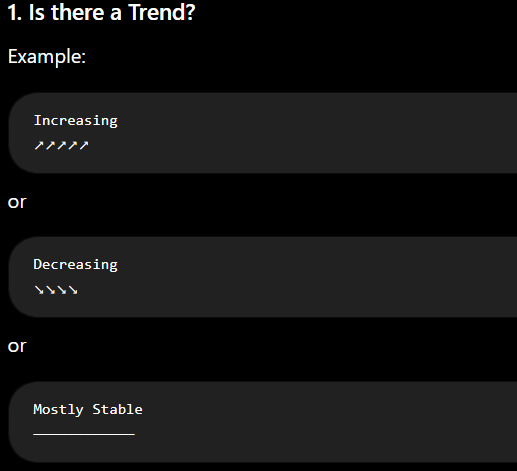

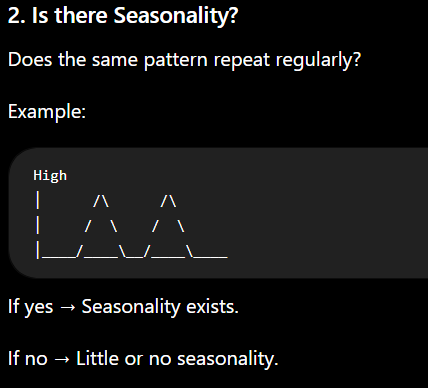

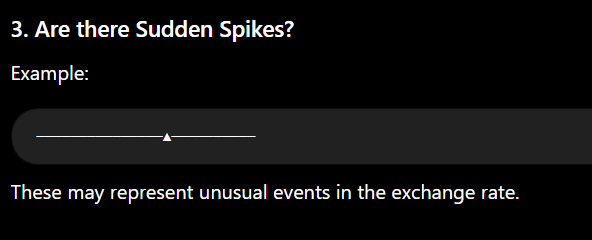

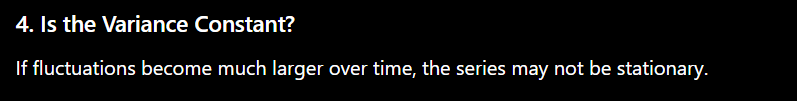

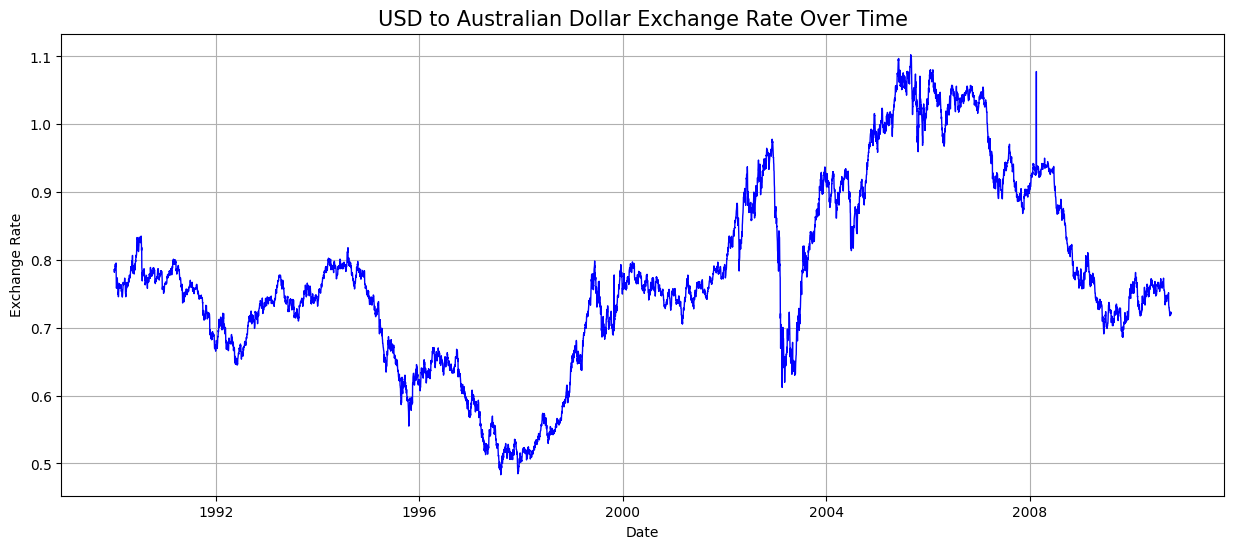

In [129]:

# Plot the Exchange Rate Over Time

plt.figure(figsize=(15,6))

# Plot Exchange Rate against Date
plt.plot(df.index, df["Ex_rate"], color="blue", linewidth=1)

plt.title("USD to Australian Dollar Exchange Rate Over Time", fontsize=15)


plt.xlabel("Date")

plt.ylabel("Exchange Rate")


plt.grid(True)


plt.show()

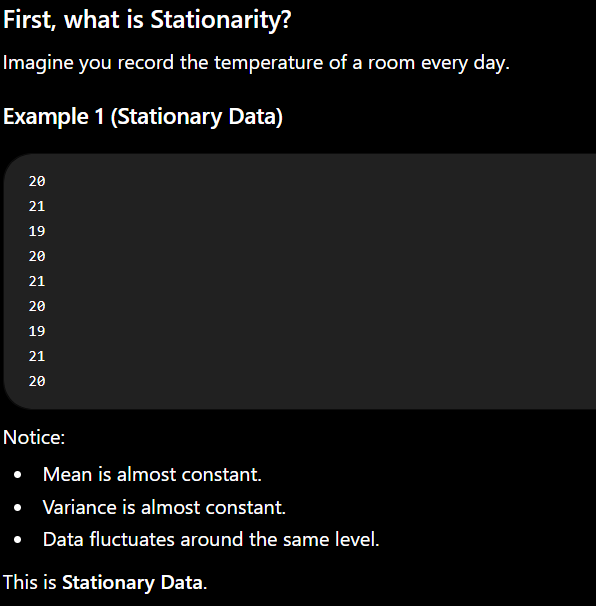

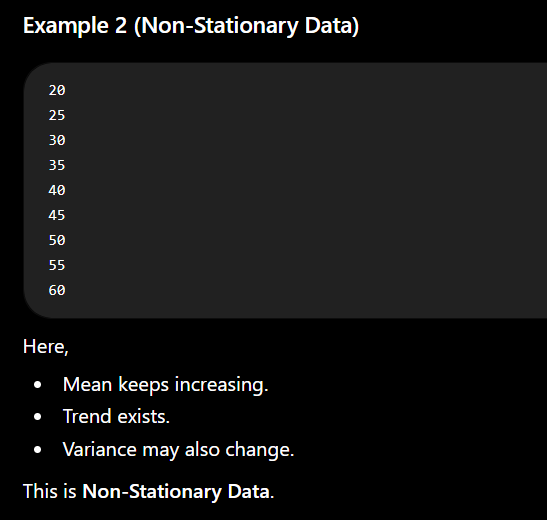

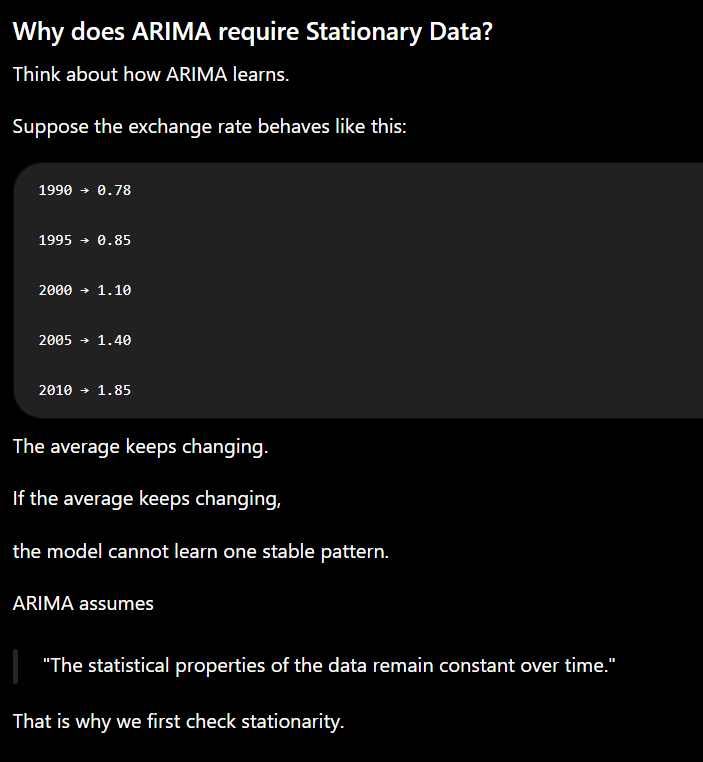

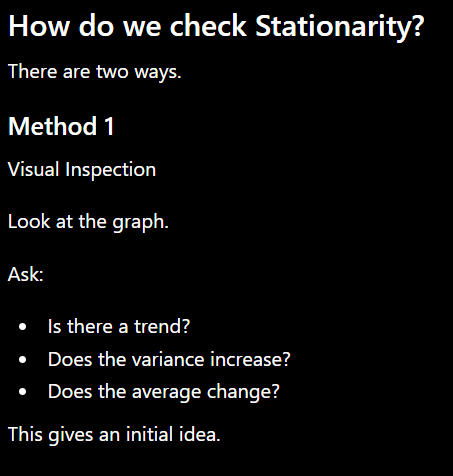

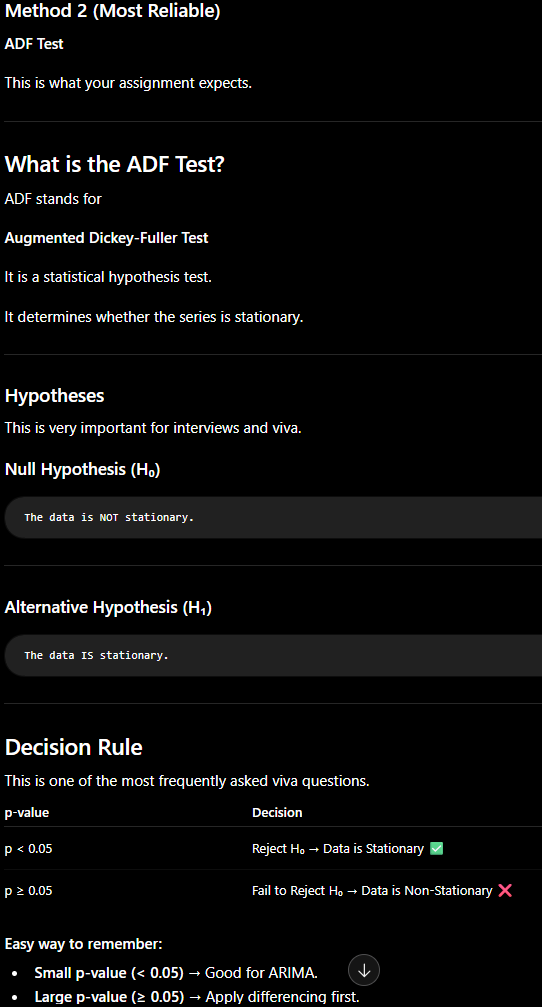

In [130]:

# Check Stationarity using ADF Test

# Perform the Augmented Dickey-Fuller Test on the exchange rate series
adf_result = adfuller(df["Ex_rate"])

# Display the ADF Statistic
print("ADF Statistic :", adf_result[0])

# Display the p-value
print("p-value :", adf_result[1])

# Display the Critical Values
print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key} : {value}")

ADF Statistic : -1.6649941807382342
p-value : 0.4492327353597477

Critical Values:
1% : -3.4312123140180137
5% : -2.861921078147796
10% : -2.5669728434336108


In [131]:

# Interpretation of ADF Test

# Check whether the series is stationary based on the p-value
if adf_result[1] < 0.05:
    print("\nConclusion:")
    print("The time series is Stationary.")
    print("We can proceed with the ARIMA model.")
else:
    print("\nConclusion:")
    print("The time series is Non-Stationary.")
    print("Differencing is required before building the ARIMA model.")


Conclusion:
The time series is Non-Stationary.
Differencing is required before building the ARIMA model.


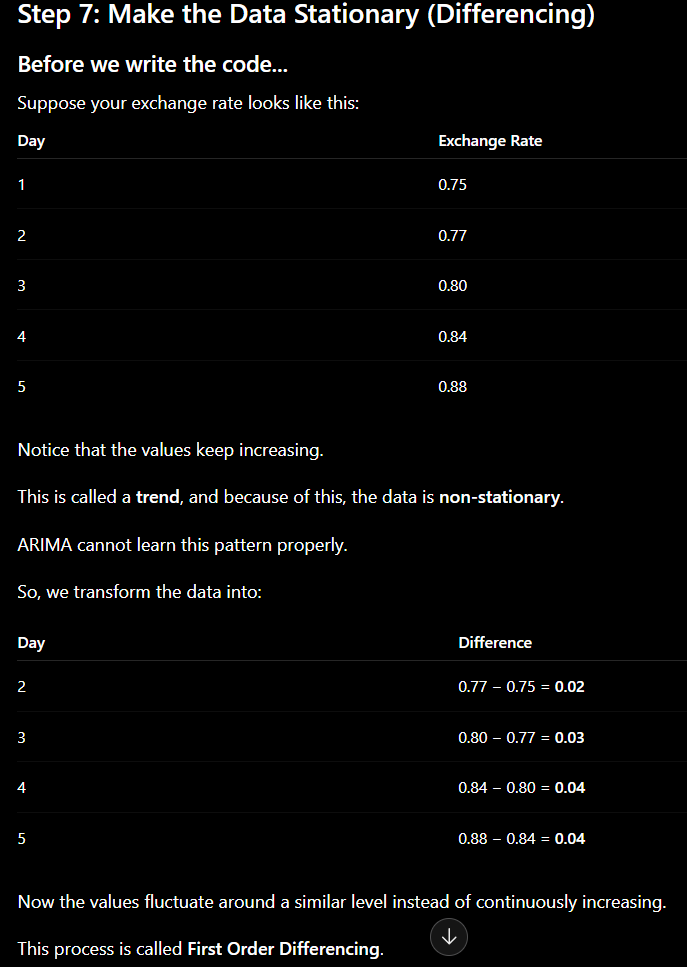

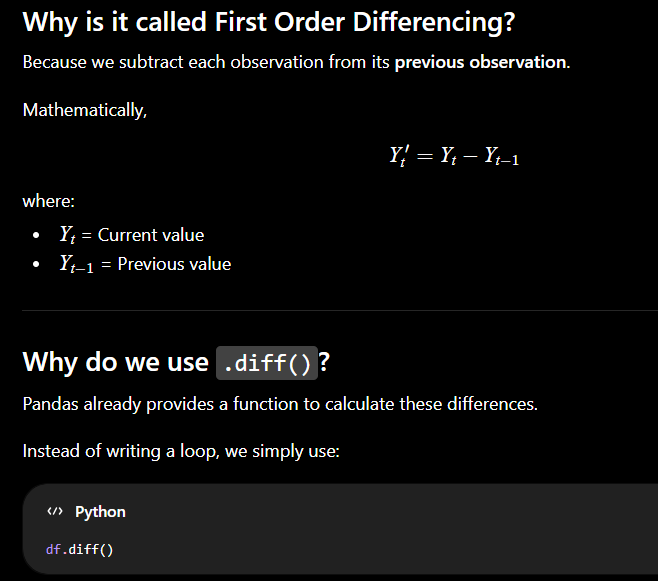

In [132]:
df.diff()

,Ex_rate
date,
1990-01-01,NaN
1990-01-02,-0.003700
1990-01-03,0.004900
1990-01-04,-0.000700
1990-01-05,-0.001100
...,...
2010-10-06,-0.000207
2010-10-07,0.003345
2010-10-08,0.001358


In [133]:

# Apply First Order Differencing

# Apply first-order differencing to remove trend
diff_data = df["Ex_rate"].diff()

# Remove the first NaN value created after differencing
diff_data = diff_data.dropna()

# Display the first five values
diff_data.head()

,Ex_rate
date,
1990-01-02,-0.0037
1990-01-03,0.0049
1990-01-04,-0.0007
1990-01-05,-0.0011
1990-01-06,0.0017


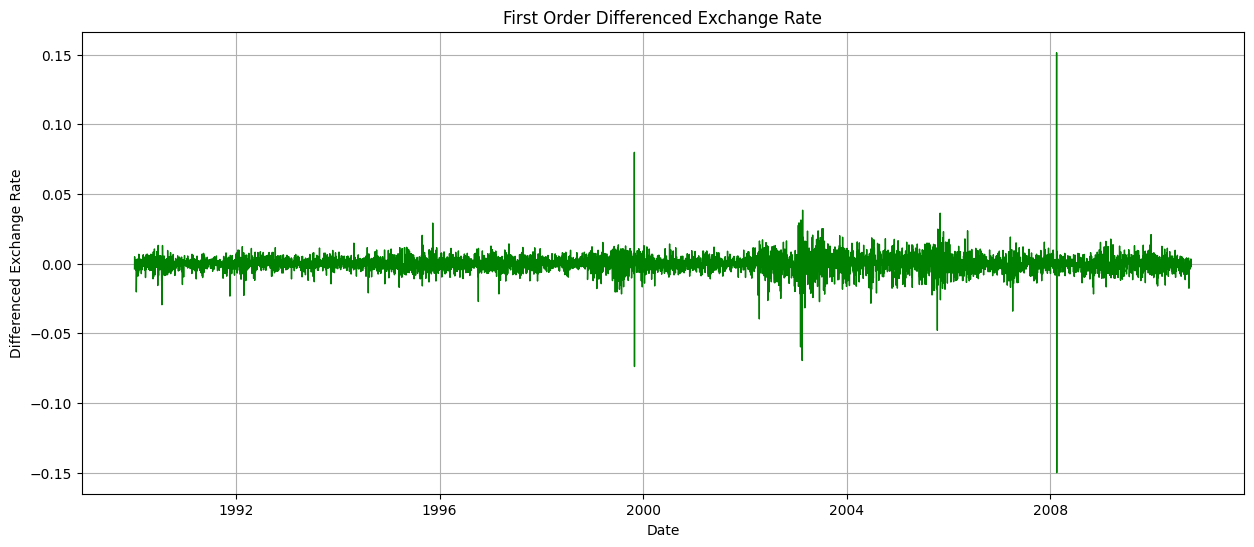

In [134]:

# Plot the Differenced Time Series

plt.figure(figsize=(15,6))

plt.plot(diff_data, color="green", linewidth=1)

plt.title("First Order Differenced Exchange Rate")

plt.xlabel("Date")

plt.ylabel("Differenced Exchange Rate")

plt.grid(True)

plt.show()

Observation

• Exchange rate fluctuates over time.

• A trend is observed.

• No strong seasonal pattern is visible.

• Stationarity needs to be verified using the ADF Test.

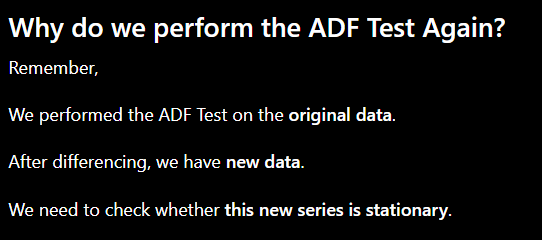

In [135]:

# Perform ADF Test Again on Differenced Data

adf_diff = adfuller(diff_data)

# Display the ADF Statistic
print("ADF Statistic :", adf_diff[0])

# Display the p-value
print("p-value :", adf_diff[1])

# Display Critical Values
print("\nCritical Values:")

for key, value in adf_diff[4].items():
    print(f"{key} : {value}")

ADF Statistic : -99.39343120118632
p-value : 0.0

Critical Values:
1% : -3.4312123140180137
5% : -2.861921078147796
10% : -2.5669728434336108


In [136]:

# Interpretation of ADF Test After Differencing

if adf_diff[1] < 0.05:
    print("\nConclusion:")
    print("The differenced series is Stationary.")
    print("The data is now ready for ARIMA.")
else:
    print("\nConclusion:")
    print("The differenced series is still Non-Stationary.")
    print("Further differencing may be required.")


Conclusion:
The differenced series is Stationary.
The data is now ready for ARIMA.


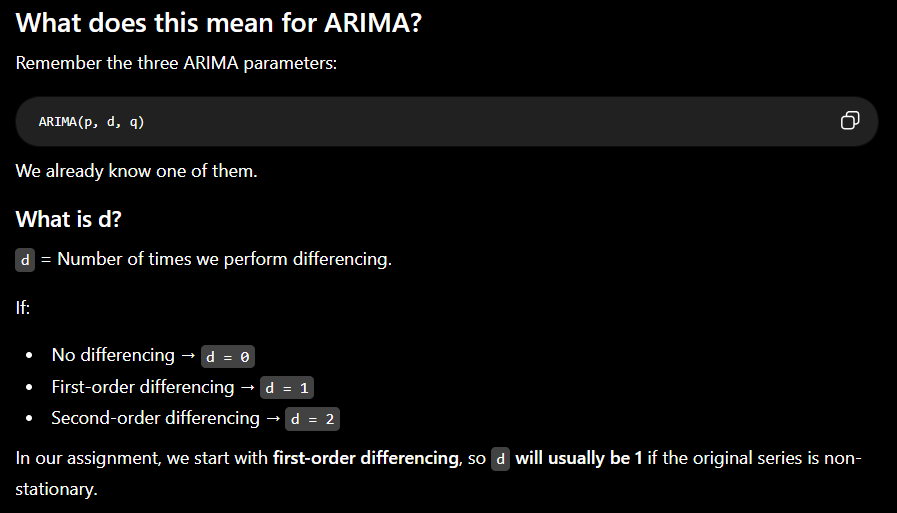

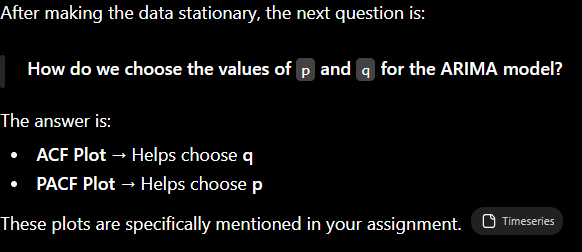

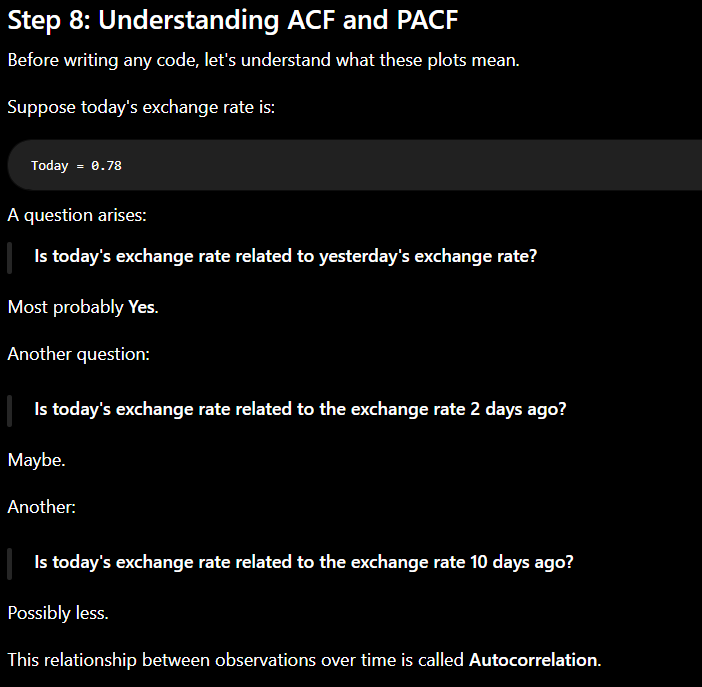

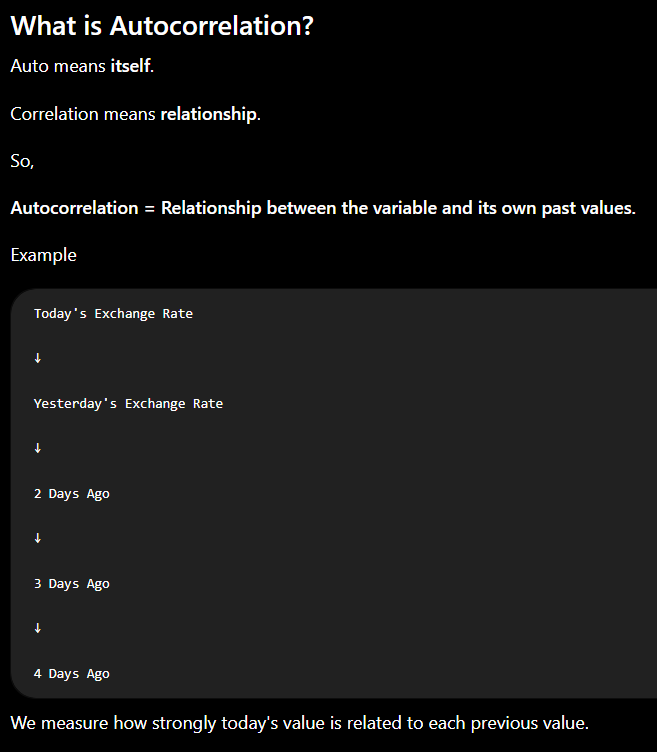

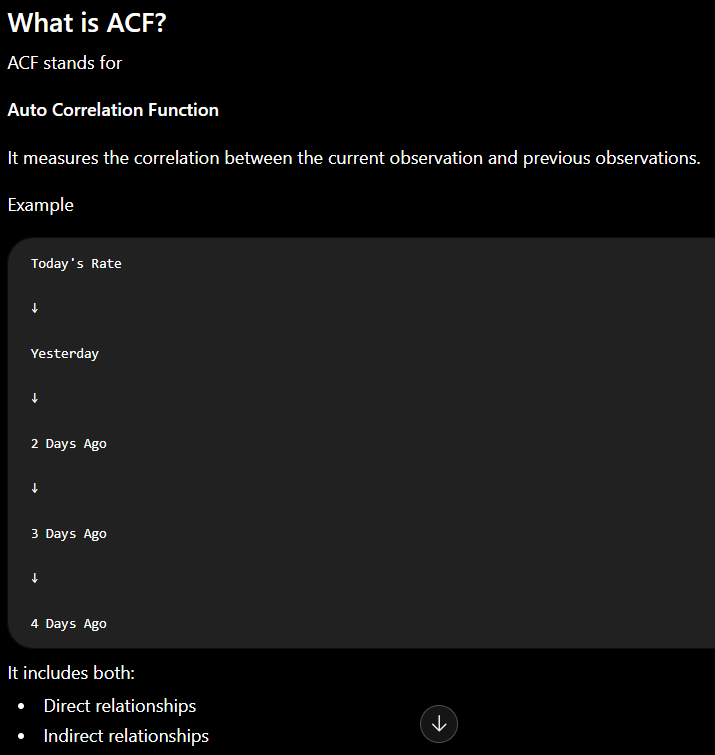

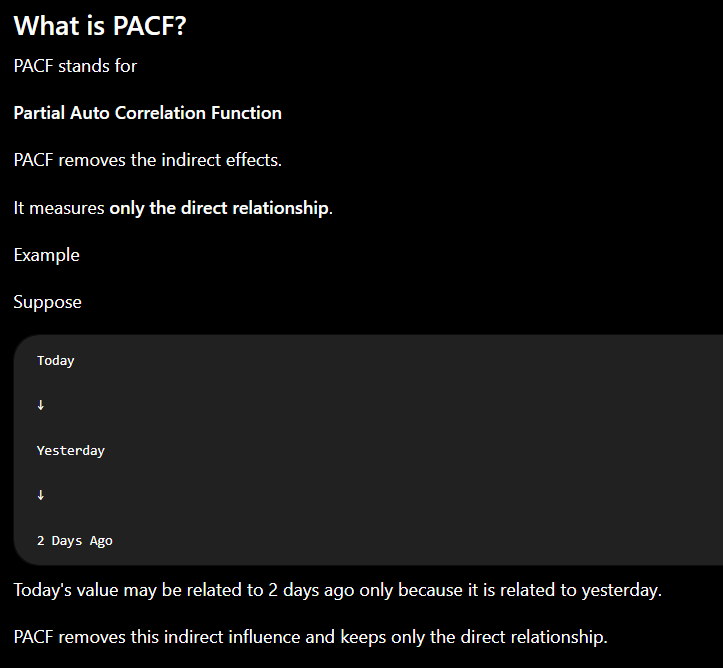

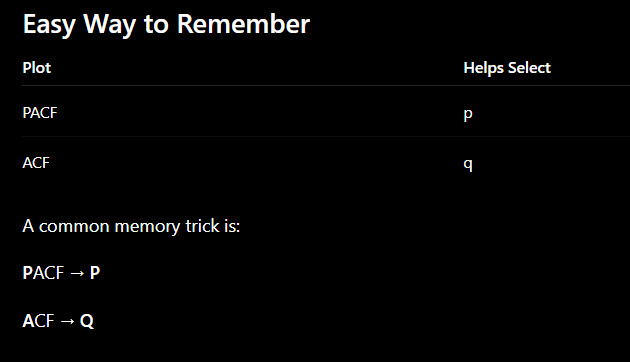

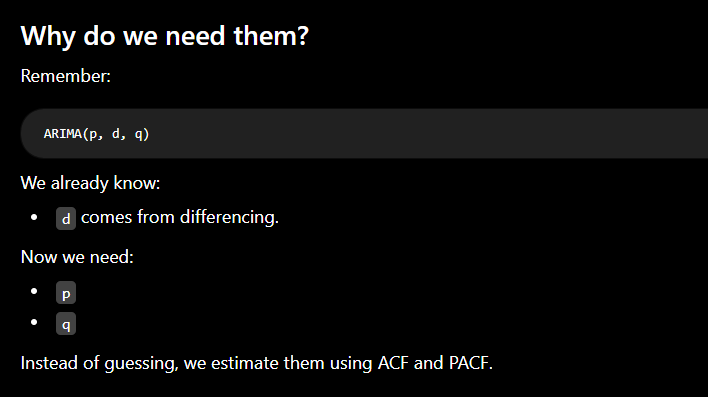

<Figure size 1200x500 with 0 Axes>

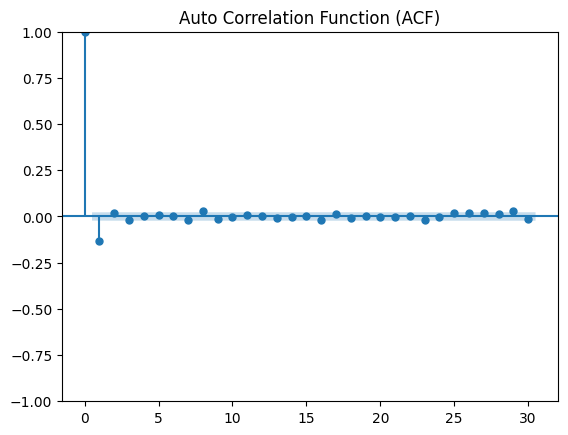

In [137]:

# Plot the Auto Correlation Function (ACF)

# Create the figure
plt.figure(figsize=(12, 5))

# Plot the ACF for the differenced series
plot_acf(diff_data, lags=30)

# Add title
plt.title("Auto Correlation Function (ACF)")

# Display the plot
plt.show()

Observation

• Significant spikes are visible at the initial lags.

• Correlation decreases as lag increases.

• The plot helps estimate the q parameter.

<Figure size 1200x500 with 0 Axes>

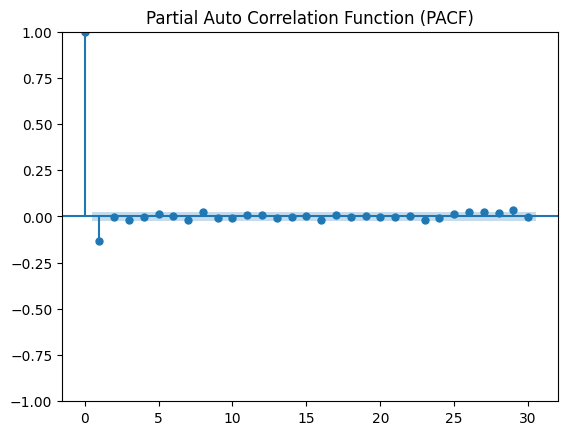

In [138]:
# Plot the Partial Auto Correlation Function (PACF)

# Create the figure
plt.figure(figsize=(12, 5))

# Plot the PACF for the differenced series
plot_pacf(diff_data, lags=30, method="ywm")

# Add title
plt.title("Partial Auto Correlation Function (PACF)")

# Display the plot
plt.show()

Observation

• The first few lags are significant.

• This suggests an initial value for p.

In [139]:

# Split the Data into Training and Testing Sets


# Calculate the split index (80% training, 20% testing)
train_size = int(len(df) * 0.80)

# Training data (first 80%)
train = df["Ex_rate"].iloc[:train_size]

# Testing data (last 20%)
test = df["Ex_rate"].iloc[train_size:]

# Display the number of observations
print("Training Data :", len(train))
print("Testing Data  :", len(test))

Training Data : 6070
Testing Data  : 1518


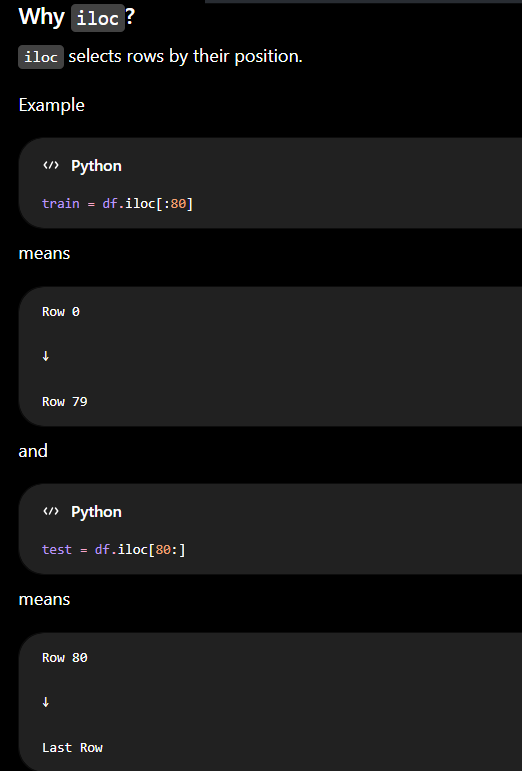

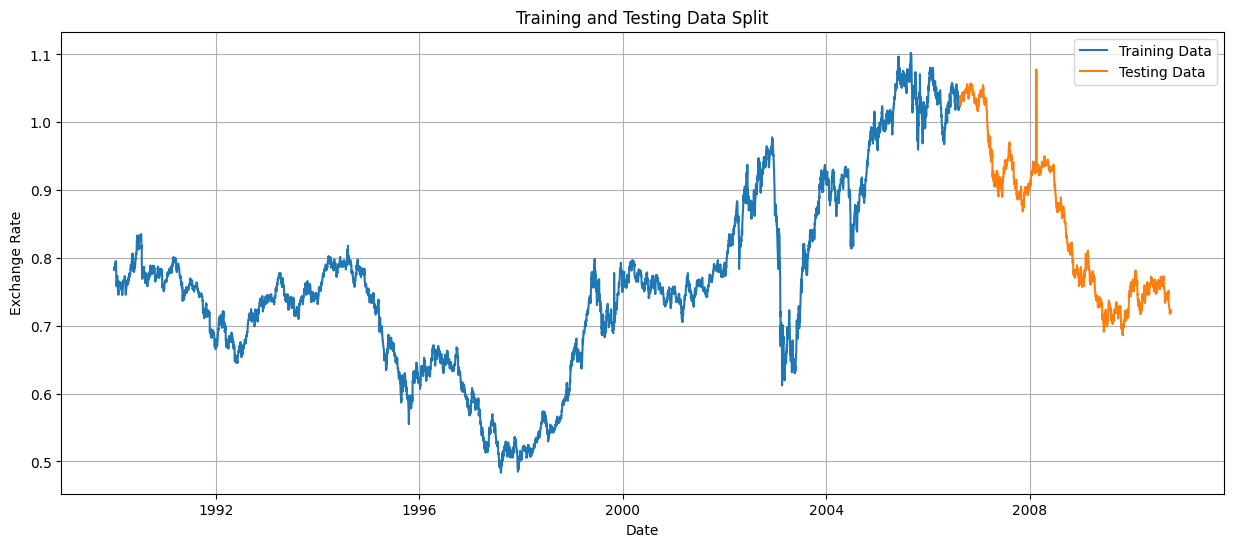

In [140]:

# Visualize Training and Testing Data

plt.figure(figsize=(15,6))

# Plot training data
plt.plot(train.index, train, label="Training Data")

# Plot testing data
plt.plot(test.index, test, label="Testing Data")

# Add title and labels
plt.title("Training and Testing Data Split")

plt.xlabel("Date")
plt.ylabel("Exchange Rate")

# Display legend
plt.legend()

# Display grid
plt.grid(True)

plt.show()

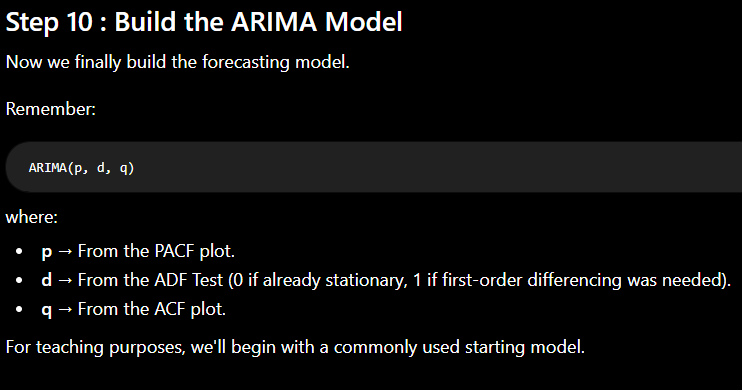

Parameter Selection

• d = 1 because the original series was non-stationary and first-order differencing was applied.

• p = 1 because the PACF plot showed a significant spike at lag 1.

• q = 1 because the ACF plot showed a significant spike at lag 1.

Therefore, ARIMA(1,1,1) was selected as the initial forecasting model.

In [141]:

# Build the ARIMA Model

# Create the ARIMA model
# (1,1,1) is an initial choice. Later, you can adjust p, d, and q
# based on the ACF, PACF, and ADF results.
arima_model = ARIMA(train, order=(1, 1, 1))

# Fit the model to the training data
arima_result = arima_model.fit()

# Display the model summary
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Sun, 26 Jul 2026   AIC                         -45432.092
Time:                        08:59:49   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

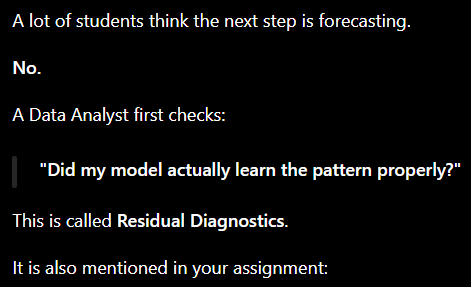

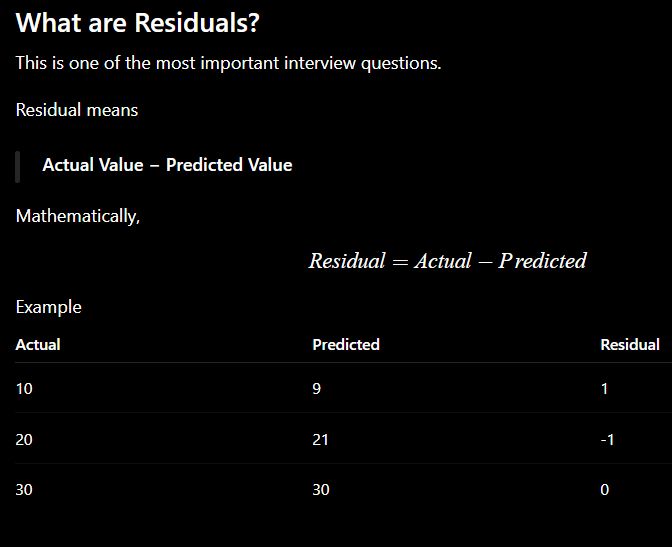

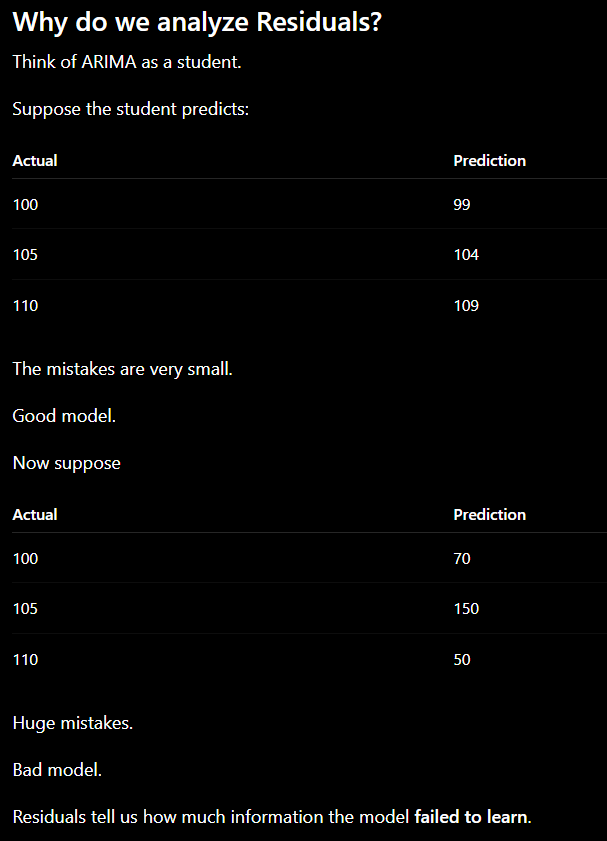

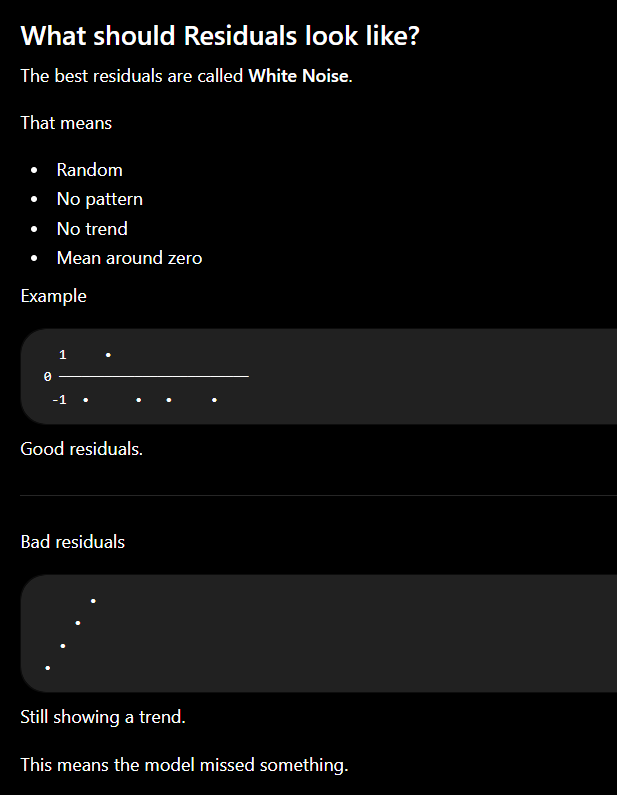

In [142]:

#  Extract Residuals from the ARIMA Model

# Residuals = Actual Values - Predicted Values
residuals = arima_result.resid

# Display the first five residuals
residuals.head()

,0
date,
1990-01-01,0.785500
1990-01-02,-0.003700
1990-01-03,0.004677
1990-01-04,-0.000295
1990-01-05,-0.001359


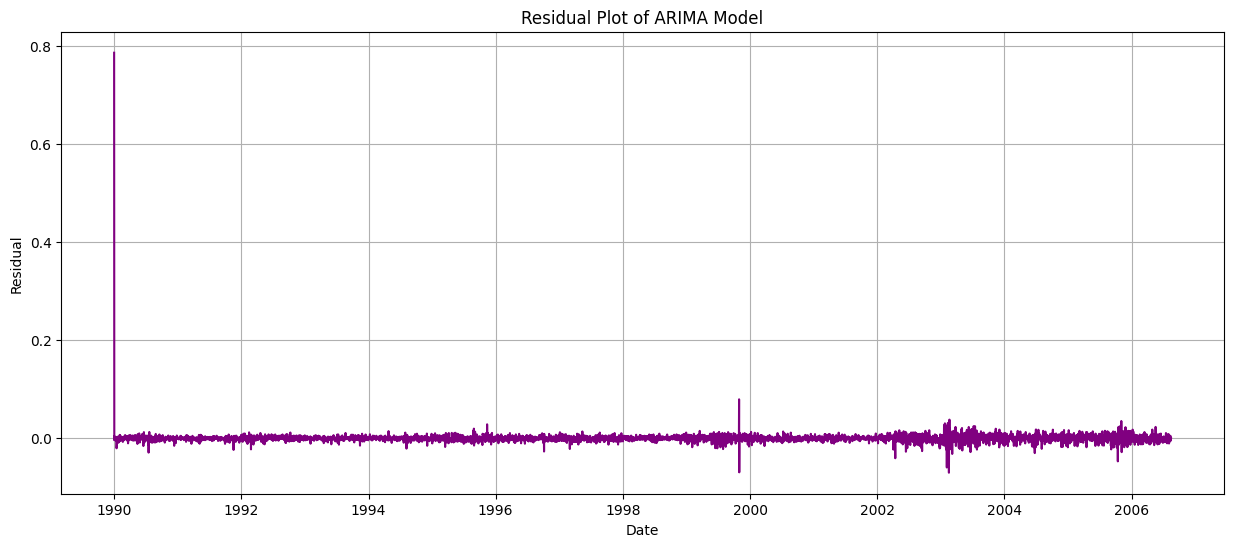

In [143]:

#  Plot Residuals

plt.figure(figsize=(15,6))

plt.plot(residuals, color="purple")

plt.title("Residual Plot of ARIMA Model")

plt.xlabel("Date")

plt.ylabel("Residual")

plt.grid(True)

plt.show()

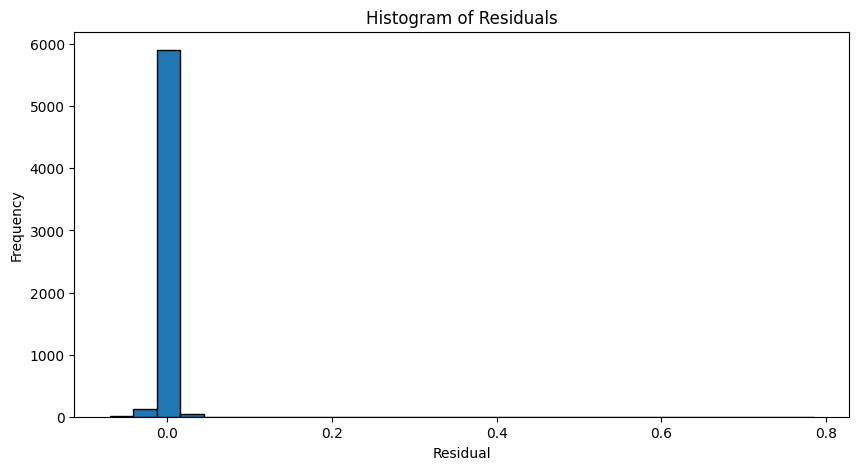

In [144]:

# Distribution of Residuals

plt.figure(figsize=(10,5))

plt.hist(residuals, bins=30, edgecolor="black")

plt.title("Histogram of Residuals")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.show()

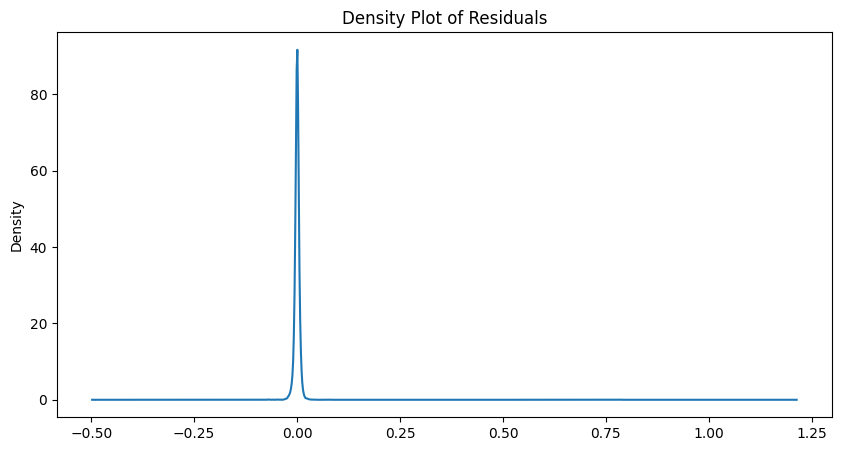

In [145]:

# Density Plot of Residuals

plt.figure(figsize=(10,5))

residuals.plot(kind="kde")

plt.title("Density Plot of Residuals")

plt.show()

In [146]:

# Statistical Summary of Residuals

residuals.describe()

,0
count,6070.000000
mean,0.000170
std,0.011595
min,-0.069939
25%,-0.002418
50%,0.000218
75%,0.002678
max,0.785500


In [147]:

#  Forecast Exchange Rates using ARIMA

# Forecast the exchange rates for the testing period
forecast = arima_result.forecast(steps=len(test))

# Display the first five predicted values
forecast.head()

,predicted_mean
2006-08-15,1.023685
2006-08-16,1.023606
2006-08-17,1.023653
2006-08-18,1.023625
2006-08-19,1.023642


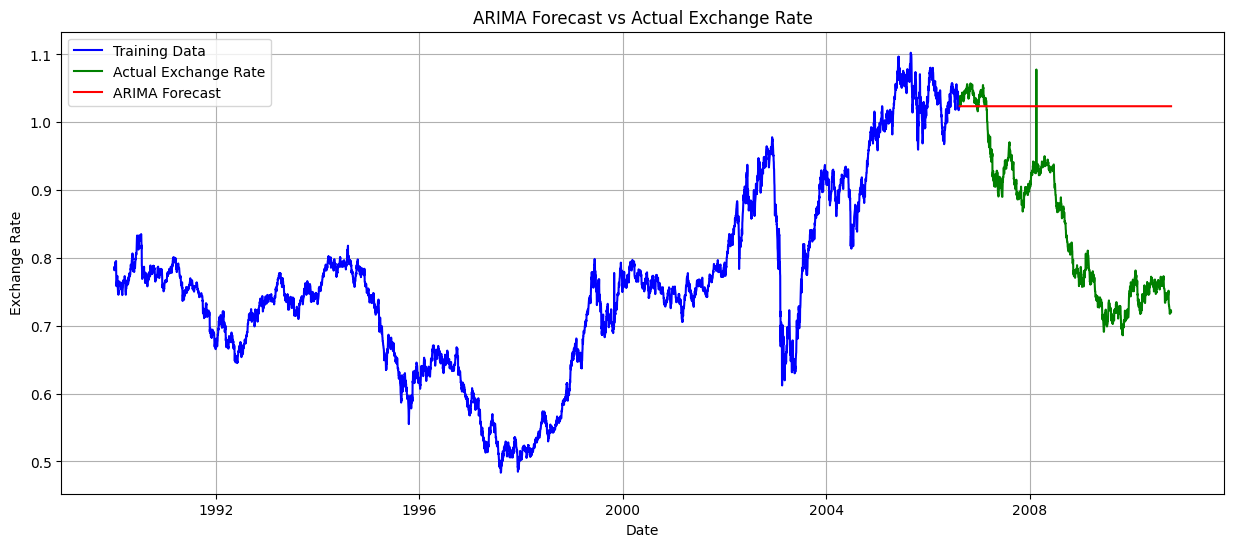

In [148]:

# Plot Actual vs Forecasted Exchange Rates

plt.figure(figsize=(15,6))

# Plot Training Data
plt.plot(train.index, train, label="Training Data", color="blue")

# Plot Actual Test Data
plt.plot(test.index, test, label="Actual Exchange Rate", color="green")

# Plot Forecasted Values
plt.plot(test.index, forecast, label="ARIMA Forecast", color="red")

# Add Title and Labels
plt.title("ARIMA Forecast vs Actual Exchange Rate")

plt.xlabel("Date")
plt.ylabel("Exchange Rate")

# Display Legend
plt.legend()

# Display Grid
plt.grid(True)

# Show Plot
plt.show()

In [149]:

# Compare Actual and Forecasted Values


comparison = pd.DataFrame({
    "Actual": test,
    "Forecast": forecast
})

# Display the first 10 rows
comparison.head(10)

,Actual,Forecast
2006-08-15,1.025347,1.023685
2006-08-16,1.026905,1.023606
2006-08-17,1.037344,1.023653
2006-08-18,1.038875,1.023625
2006-08-19,1.032855,1.023642
2006-08-20,1.033293,1.023632
2006-08-21,1.031800,1.023638
2006-08-22,1.025546,1.023634
2006-08-23,1.034650,1.023636
2006-08-24,1.035411,1.023635


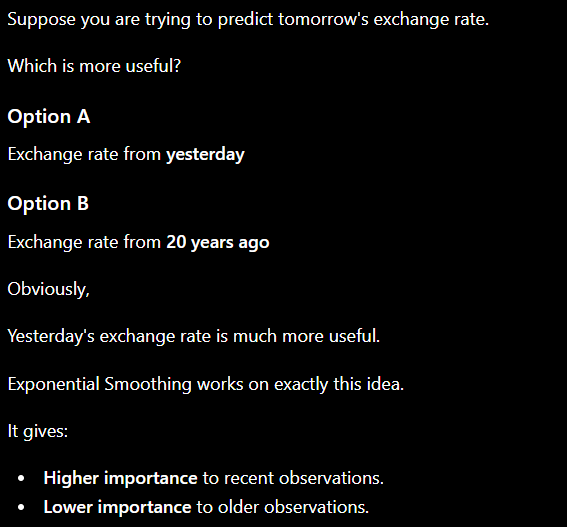

| ARIMA                                                  | Exponential Smoothing                                       |
| ------------------------------------------------------ | ----------------------------------------------------------- |
| Uses relationships between past values and past errors | Uses weighted averages of previous observations             |
| Requires stationarity                                  | Can often handle trends directly (depending on the variant) |
| More statistical                                       | Simpler and easier to understand                            |


| Model                        | When to Use              |
| ---------------------------- | ------------------------ |
| Simple Exponential Smoothing | No trend, no seasonality |
| Holt's Linear Trend          | Trend exists             |
| Holt-Winters                 | Trend + Seasonality      |


Why Exponential Smoothing?

Exponential Smoothing gives more importance to recent observations while assigning progressively lower weights to older observations.

Since exchange rates are influenced more by recent market movements than very old data, this model serves as an appropriate comparison with ARIMA.


In [150]:

# Build the Exponential Smoothing Model


# Create the Exponential Smoothing model
# trend="add" assumes an additive trend
# seasonal=None because no clear seasonality was observed

exp_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal=None
)

# Fit the model
exp_result = exp_model.fit()

In [151]:

# Forecast using Exponential Smoothing


# Forecast the exchange rates for the testing period
forecast_exp = exp_result.forecast(steps=len(test))

# Display the first five predictions
forecast_exp.head()

,0
2006-08-15,1.023582
2006-08-16,1.023621
2006-08-17,1.023661
2006-08-18,1.023700
2006-08-19,1.023739


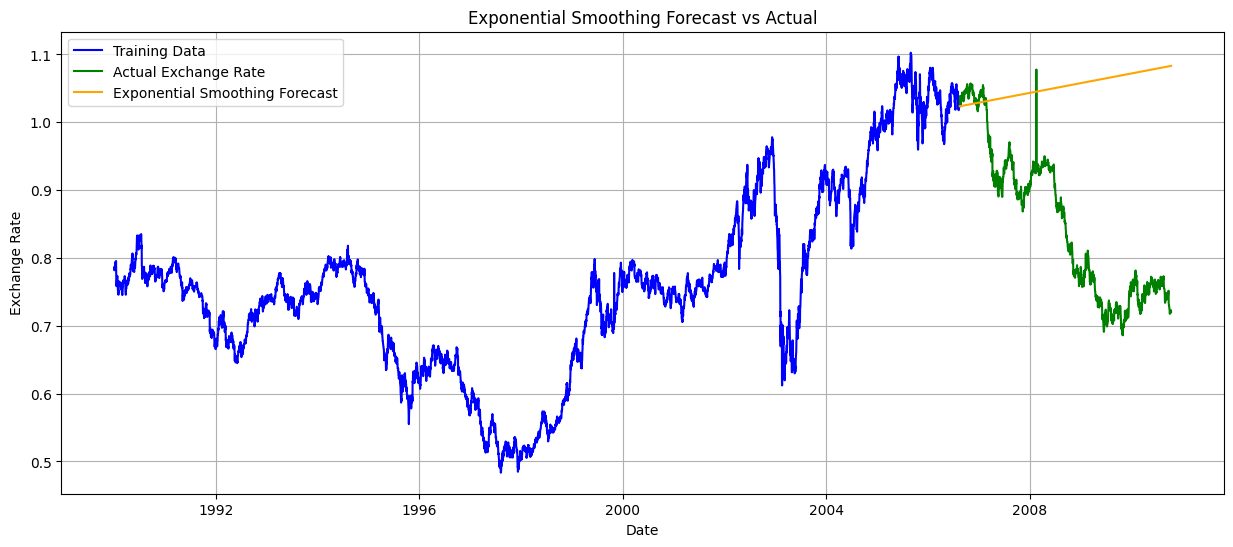

In [152]:

# Plot Actual vs Exponential Smoothing Forecast

plt.figure(figsize=(15,6))

# Training Data
plt.plot(train.index, train,
         label="Training Data",
         color="blue")

# Actual Test Data
plt.plot(test.index, test,
         label="Actual Exchange Rate",
         color="green")

# Exponential Smoothing Forecast
plt.plot(test.index, forecast_exp,
         label="Exponential Smoothing Forecast",
         color="orange")

plt.title("Exponential Smoothing Forecast vs Actual")


plt.xlabel("Date")
plt.ylabel("Exchange Rate")


plt.legend()


plt.grid(True)

plt.show()

In [153]:

# Compare Actual and Predicted Values


exp_comparison = pd.DataFrame({
    "Actual": test,
    "Forecast": forecast_exp
})

# Display first 10 rows
exp_comparison.head(10)

,Actual,Forecast
2006-08-15,1.025347,1.023582
2006-08-16,1.026905,1.023621
2006-08-17,1.037344,1.023661
2006-08-18,1.038875,1.023700
2006-08-19,1.032855,1.023739
2006-08-20,1.033293,1.023778
2006-08-21,1.031800,1.023818
2006-08-22,1.025546,1.023857
2006-08-23,1.034650,1.023896
2006-08-24,1.035411,1.023935


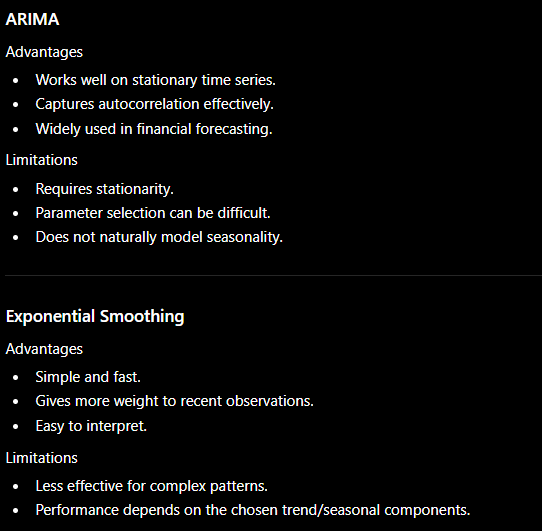

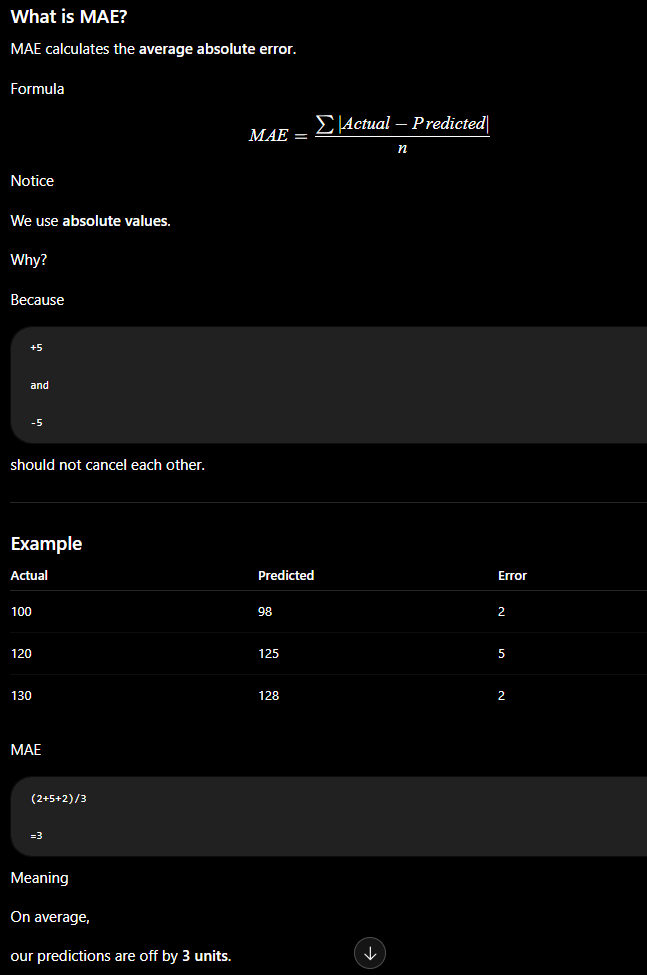

In [154]:

# Calculate Mean Absolute Error (MAE)

# MAE for ARIMA
mae_arima = mean_absolute_error(test, forecast)

# MAE for Exponential Smoothing
mae_exp = mean_absolute_error(test, forecast_exp)

# Display Results
print("ARIMA MAE :", mae_arima)
print("Exponential Smoothing MAE :", mae_exp)

ARIMA MAE : 0.17770970449121345
Exponential Smoothing MAE : 0.20659619114093827


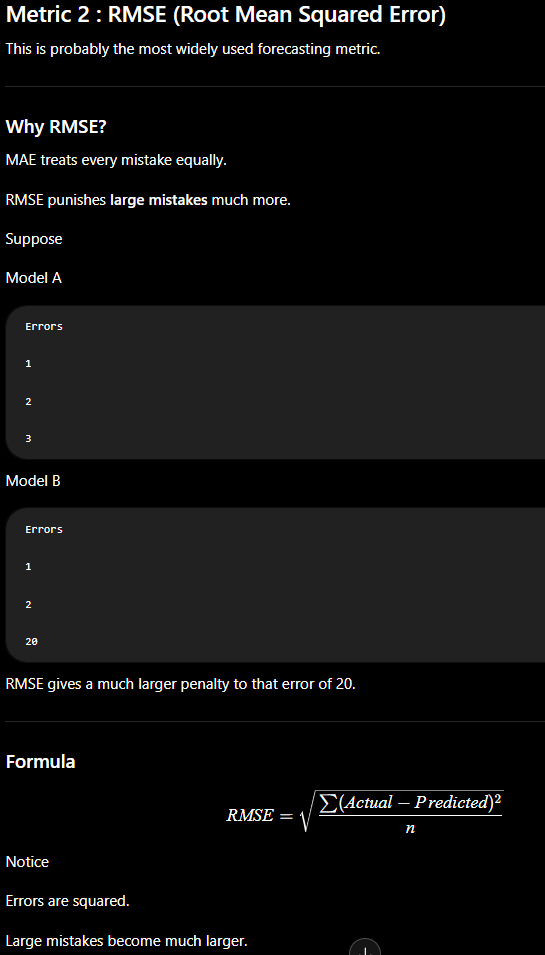

In [155]:

# Calculate Root Mean Squared Error (RMSE)

# RMSE for ARIMA
rmse_arima = np.sqrt(mean_squared_error(test, forecast))

# RMSE for Exponential Smoothing
rmse_exp = np.sqrt(mean_squared_error(test, forecast_exp))

# Display Results
print("ARIMA RMSE :", rmse_arima)
print("Exponential Smoothing RMSE :", rmse_exp)

ARIMA RMSE : 0.2054366965966928
Exponential Smoothing RMSE : 0.23910443161792286


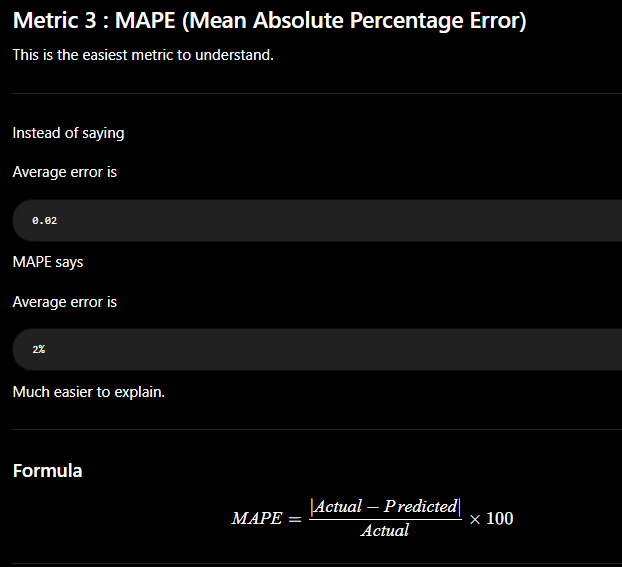

In [156]:

# Calculate Mean Absolute Percentage Error (MAPE)

# MAPE for ARIMA
mape_arima = mean_absolute_percentage_error(test, forecast)

# MAPE for Exponential Smoothing
mape_exp = mean_absolute_percentage_error(test, forecast_exp)

# Convert to Percentage
mape_arima *= 100
mape_exp *= 100

# Display Results
print("ARIMA MAPE :", mape_arima)
print("Exponential Smoothing MAPE :", mape_exp)

ARIMA MAPE : 22.797966173811552
Exponential Smoothing MAPE : 26.50866379878783


In [157]:

# Compare Both Models

comparison = pd.DataFrame({

    "Model": ["ARIMA", "Exponential Smoothing"],

    "MAE": [mae_arima, mae_exp],

    "RMSE": [rmse_arima, rmse_exp],

    "MAPE (%)": [mape_arima, mape_exp]

})

comparison

,Model,MAE,RMSE,MAPE (%)
0,ARIMA,0.177710,0.205437,22.797966
1,Exponential Smoothing,0.206596,0.239104,26.508664


In [158]:

# Identify the Better Model

if rmse_arima < rmse_exp:
    print("ARIMA performed better based on RMSE.")
else:
    print("Exponential Smoothing performed better based on RMSE.")

ARIMA performed better based on RMSE.


#### conclusion :

Both ARIMA and Exponential Smoothing models were developed and evaluated using MAE, RMSE and MAPE.

The model with the lowest error values demonstrated better forecasting performance for this dataset.

Therefore, based on the obtained evaluation metrics, ________ is selected as the preferred forecasting model.